In [60]:
import pandas as pd

data = pd.read_csv("data disinformasi-hoaks.csv")
data

,title,content,classification
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",hoax
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,disinformation
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",hoax
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",disinformation
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,hoax
...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,hoax
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,hoax
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,hoax
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,hoax


In [61]:
data["content"][0]

'Beredar di media sosial, sebuah informasi yang mengklaim bahwa Indomilk atau PT Indolakto tengah membagikan hadiah jutaan rupiah dalam rangka perayaan ulang tahun ke-55 Indomilk. Unggahan tersebut disertai dengan sebuah tautan yang berisi kuesioner untuk mendapatkan hadiah..<div><br></div><div>Faktanya, melalui akun Instagram resminya @indomilk.kentalmanis, PT Indolakto membantah informasi yang beredar tersebut. Pihaknya mengimbau masyarakat untuk tetap berhati-hati terhadap modus penipuan yang mengatasnamakan Indomilk.</div>'

In [62]:
data.isna().sum()

title                0
content           2857
classification       0
dtype: int64

In [63]:
data_kosong = data[data["content"].isna()]
data_nonkosong = data[data["content"].notna()]

In [64]:
data_nonkosong["banyak_kata_content"] = data_nonkosong["content"].str.split().str.len()
data_kosong["banyak_kata_title"] = data_kosong["title"].str.split().str.len()

# buat judul
data_nonkosong["banyak_kata_title"] = data_nonkosong["title"].str.split().str.len()

C:\Users\Dipo\AppData\Local\Temp\ipykernel_316068\2188282666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_nonkosong["banyak_kata_content"] = data_nonkosong["content"].str.split().str.len()
C:\Users\Dipo\AppData\Local\Temp\ipykernel_316068\2188282666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_kosong["banyak_kata_title"] = data_kosong["title"].str.split().str.len()
C:\Users\Dipo\AppData\Local\Temp\ipykernel_316068\2188282666.py:5: SettingWithCopyWarning: 
A value is trying to be set 

In [65]:
data_nonkosong["banyak_kata_content"].min()


1

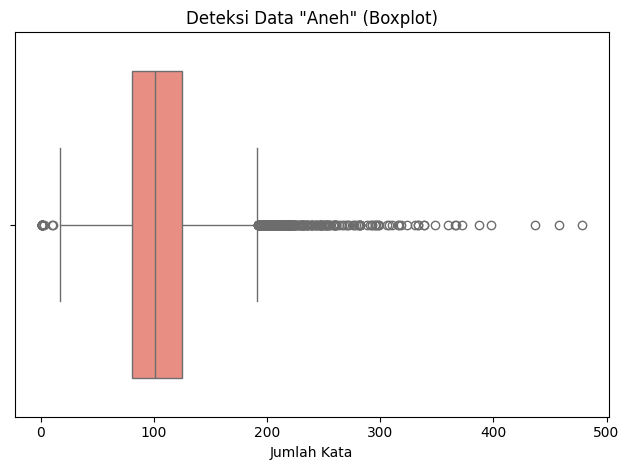

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=data_nonkosong['banyak_kata_content'], color='salmon')
plt.title('Deteksi Data "Aneh" (Boxplot)')
plt.xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

In [68]:
anomali = data_nonkosong[(data_nonkosong["banyak_kata_content"] <= 20) | (data_nonkosong["banyak_kata_title"] <= 1)]

In [69]:
anomali

,title,content,classification,banyak_kata_content,banyak_kata_title
631,test 12 januari,tes,disinformation,1,3
1270,"“OPERAIND""",Beberapa waktu belakangan banyak beredar berit...,hoax,109,1
2218,Judul isu dua,Narasi isu dua,hoax,3,3
6323,ina minta Jokowi jual pulau jawa dan sumatra,empty,hoax,1,8
6342,eluarga menutup keranda mayit dengan karpet ak...,empty,hoax,1,14
6792,Survei kemenangan Prabowo,empty,hoax,1,3
7056,tes title diganti,Warteg di Pasar Pramuka Mengalami Kerugian Set...,hoax,10,3
7918,tes7jul,hasil periksa fakta Rahmah a n (UIN Sunan Ampe...,misinformation,25,1
13169,rabowo Sandi dinanti dunia !,"Foto yang beredar adalah hasil suntingan, meng...",hoax,19,5
13629,odus pencurian menggunakan Stiker Call Center ...,empty,hoax,1,13


In [72]:
mask_anomali = (data_nonkosong["banyak_kata_content"] <= 20) | (data_nonkosong["banyak_kata_title"] <= 1)

In [73]:
anomali = data_nonkosong[mask_anomali]
noAnomali = data_nonkosong[~mask_anomali]

In [74]:
noAnomali

,title,content,classification,banyak_kata_content,banyak_kata_title
0,Indomilk Bagi-bagi Hadiah Jutaan Rupiah,"Beredar di media sosial, sebuah informasi yang...",hoax,61,5
1,"Video Buaya Memakan Orang di Daerah Bodeh, Com...",Beredar sebuah foto di media sosial yang mempe...,disinformation,86,11
2,Presiden Jokowi Resmikan Bendera Indonesia Ter...,"<div style=""text-align: justify;"">Beredar di m...",hoax,74,6
3,Tautan Hadiah Khusus Nasabah BPD Bali,"<div style=""text-align: justify;"">Beredar bebe...",disinformation,92,6
4,Akun WhatsApp Palsu Mengatasnamakan Kepala Din...,Beredar informasi di media sosial sebuah akun ...,hoax,82,9
...,...,...,...,...,...
16942,Puan Maharani Informasikan Dana Bantuan untuk ...,Beredar sebuah unggahan video di media sosial ...,hoax,109,8
16943,Tautan Pendaftaran Undian Berhadiah Bank Sulut...,Beredar sebuah unggahan di media sosial Facebo...,hoax,125,7
16944,Tautan Pendaftaran Seleksi Guru Sekolah Garuda...,Beredar unggahan video di media sosial TikTok ...,hoax,161,8
16945,Foto Pemain Timnas Bulgaria Tiba di Indonesia ...,Beredar sebuah unggahan di media sosial yang ...,hoax,109,10
